### Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import emoji
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
import spacy
from collections import Counter

In [2]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('word_tokenize')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Error loading word_tokenize: Package 'word_tokenize' not
[nltk_data]     found in index


# <div style="text-align: center; background-color: white; font-family: Lobster;color: black; padding: 14px; line-height: 1;border-radius:12px"> Pre-processing "Posts.csv" </div>

In [3]:
posts_df = pd.read_csv(r'C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\data\clean\clean_posts.csv')
posts_df.head()

,post_id,timestamp,postUser,caption,hashtags,likesCount,commentsCount
0,1,2023-06-02 16:34:43+00:00,maryleest,Cannes 2023 with @kilianparis 🤍 #KilianCannes ...,KilianCannes,32070,142
1,2,2023-01-01 07:49:16+00:00,tinaabeysekara,"As the clock struck midnight to ring in 2022, ...",no_hashtag,6565,86
2,3,2023-05-29 18:57:51+00:00,maryleest,The famous stairs 🤎 Photo @gustave_durin Dre...,no_hashtag,28936,123
3,4,2023-03-07 19:30:42+00:00,stephaniebroek,I visualized this moment so many times before....,CHANELFallWinter,4764,215
4,5,2023-05-23 21:11:12+00:00,maryleest,Got to witness such historical moment in cinem...,CannesFilmFestival,13379,123


In [4]:
posts_df.isnull().sum()

post_id          0
timestamp        0
postUser         0
caption          0
hashtags         0
likesCount       0
commentsCount    0
dtype: int64

In [5]:
# Type of each column
posts_df['timestamp'] = pd.to_datetime(posts_df['timestamp'])
posts_df.dtypes   

post_id                        int64
timestamp        datetime64[ns, UTC]
postUser                      object
caption                       object
hashtags                      object
likesCount                     int64
commentsCount                  int64
dtype: object

### "Caption" column 

In [6]:
def preprocess_caption(text):
    if pd.isna(text) or text == 'no_caption':
        return ""
    
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # Remove URLs
    text = re.sub(r'<.*?>', '', text)  # Remove HTML tags
    
    # Keep alphanumeric, whitespace, and emoji characters, replace others with space
    text = re.sub(r'[^\w\s\U0001F000-\U0001F9FF]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip() 
    
    return text

posts_df['clean_caption'] = posts_df['caption'].apply(preprocess_caption)

In [7]:
# Process Emoji in caption
def process_emoji(text):
    """
    Process emojis in text.
    Returns text without emojis and list of emoji descriptions.
    """
    emojis_list = [c for c in text if c in emoji.EMOJI_DATA]
    
    emoji_descriptions = []
    for e in emojis_list:
        emoji_name = emoji.demojize(e).replace(':', '').replace('_', ' ')
        emoji_descriptions.append(emoji_name)
    
    text_without_emoji = ''.join(c for c in text if c not in emoji.EMOJI_DATA)
    
    return text_without_emoji, emoji_descriptions

posts_df[['caption_no_emoji', 'emoji_descriptions']] = posts_df['clean_caption'].apply(lambda x: pd.Series(process_emoji(x)))


In [8]:
posts_df.head()

,post_id,timestamp,postUser,caption,hashtags,likesCount,commentsCount,clean_caption,caption_no_emoji,emoji_descriptions
0,1,2023-06-02 16:34:43+00:00,maryleest,Cannes 2023 with @kilianparis 🤍 #KilianCannes ...,KilianCannes,32070,142,cannes 2023 with kilianparis 🤍 kiliancannes we...,cannes 2023 with kilianparis kiliancannes wea...,[white heart]
1,2,2023-01-01 07:49:16+00:00,tinaabeysekara,"As the clock struck midnight to ring in 2022, ...",no_hashtag,6565,86,as the clock struck midnight to ring in 2022 i...,as the clock struck midnight to ring in 2022 i...,"[woman dancing, medium skin tone, dizzy, mediu..."
2,3,2023-05-29 18:57:51+00:00,maryleest,The famous stairs 🤎 Photo @gustave_durin Dre...,no_hashtag,28936,123,the famous stairs 🤎 photo gustave_durin dress ...,the famous stairs photo gustave_durin dress m...,[brown heart]
3,4,2023-03-07 19:30:42+00:00,stephaniebroek,I visualized this moment so many times before....,CHANELFallWinter,4764,215,i visualized this moment so many times before ...,i visualized this moment so many times before ...,"[white heart, black heart]"
4,5,2023-05-23 21:11:12+00:00,maryleest,Got to witness such historical moment in cinem...,CannesFilmFestival,13379,123,got to witness such historical moment in cinem...,got to witness such historical moment in cinem...,[broken heart]


### "Hashtags" column

In [9]:
# Process hashtags from hashtag column
def process_hashtags_from_column(hashtag_text):
    if pd.isna(hashtag_text) or hashtag_text == 'no_hashtag' or hashtag_text == '':
        return []
    
    if hashtag_text.startswith('[') and hashtag_text.endswith(']'):
        hashtag_text = hashtag_text[1:-1]
        
        tags = [tag.strip().strip("'").strip('"') for tag in hashtag_text.split(',')]
    else:
        tags = [tag.strip().strip('#') for tag in re.split(r'[,#]', hashtag_text) if tag.strip()]
    
    processed_hashtags = []
    for tag in tags:
        if tag:
            words = re.findall(r'[A-Z]?[a-z]+|[A-Z]+(?=[A-Z]|$)', tag)
            if not words:
                words = [tag]
            processed_hashtags.extend([word.lower() for word in words])
    
    return processed_hashtags

posts_df['hashtags'] = posts_df['hashtags'].apply(process_hashtags_from_column)

In [10]:
# Tokenize and remove stopwords
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

def tokenize_and_remove_stopwords(text):
    
    tokens = word_tokenize(text)
    
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word not in stop_words and word not in string.punctuation]
    
    return filtered_tokens

posts_df['caption_tokens'] = posts_df['caption_no_emoji'].apply(tokenize_and_remove_stopwords)

In [11]:
posts_df['combined_tokens'] = posts_df.apply(lambda row: row['caption_tokens'] + row['emoji_descriptions'] + row['hashtags'], axis=1)

In [12]:
posts_df['token_text'] = posts_df['combined_tokens'].apply(lambda x: ' '.join(x))

In [13]:
def extract_keywords_tfidf(df, min_df=2):
    """Trích xuất từ khóa sử dụng TF-IDF"""
    # Khởi tạo và huấn luyện TF-IDF
    tfidf = TfidfVectorizer(min_df=min_df)
    tfidf_matrix = tfidf.fit_transform(df['token_text'])
    
    # Lấy tên các feature (từ khóa)
    feature_names = tfidf.get_feature_names_out()
    print(f"Số lượng từ khóa sau khi áp dụng TF-IDF: {len(feature_names)}")
    
    # Tạo hàm trích xuất từ khóa cho mỗi bài đăng
    def get_post_keywords(text, top_n=5):
        # Chuyển văn bản thành vector TF-IDF
        text_vector = tfidf.transform([text])
        
        # Lấy điểm số cho mỗi từ
        scores = zip(feature_names, text_vector.toarray()[0])
        
        # Sắp xếp theo điểm số và lấy top N
        sorted_scores = sorted(scores, key=lambda x: x[1], reverse=True)
        
        # Trả về các từ khóa có điểm số > 0
        return [word for word, score in sorted_scores[:top_n] if score > 0]
    
    # Áp dụng cho mỗi bài đăng
    df['keywords_tfidf'] = df['token_text'].apply(
        lambda x: get_post_keywords(x)
    )
    
    return df, tfidf, feature_names

posts_df, tfidf, feature_names = extract_keywords_tfidf(posts_df)

Số lượng từ khóa sau khi áp dụng TF-IDF: 3341


In [14]:
def extract_keywords_frequency(df, top_n=5):
    """Trích xuất từ khóa dựa trên tần suất xuất hiện"""
    def get_frequent_keywords(tokens, n=top_n):
        # Đếm tần suất
        counter = Counter(tokens)
        
        # Lấy các từ khóa phổ biến nhất
        return [word for word, count in counter.most_common(n)]
    
    # Áp dụng cho mỗi bài đăng
    df['keywords_freq'] = df['combined_tokens'].apply(get_frequent_keywords)
    
    return df


posts_df = extract_keywords_frequency(posts_df)

In [15]:
def extract_weighted_keywords(df, top_n=5):    
    important_categories = {
        'events': [
            'cannes', 'festival', 'gala', 'premiere', 'show', 'fashionweek', 
            'metgala', 'runway', 'awards', 'ceremony', 'redcarpet', 'exclusiveevent',
            'cannesfilmfestival', 'parisfashionweek', 'mfw', 'pfw', 'nyfw', 'lfw'
        ],
        'years': [
            '2025', '2024', '2023', '2022', '2021', '2020', '2019', '2018'
        ],
        'brands': [
            'kilian', 'dior', 'chanel', 'gucci', 'louisvuitton', 'prada', 'adidas',
            'versace', 'fendi', 'burberry', 'hermes', 'armani', 'givenchy', 
            'balenciaga', 'valentino', 'saintlaurent', 'bottegaveneta', 'celine', 
            'loewe', 'moschino', 'alexandermcqueen', 'offwhite', 'ysl', 'miu', 'ganni'
        ],
        'fashion': [
            'wear', 'dress', 'style', 'outfit', 'fashion', 'trend', 'runwaylook', 
            'couture', 'chic', 'glamour', 'haute', 'streetstyle', 'accessories', 
            'shoes', 'handbag', 'jewelry', 'luxuryfashion', 'editorial', 'aesthetic',
            'designer', 'minimal', 'maximal', 'vintage', 'avantgarde', 'moda', 'looks'
        ],
        'locations': [
            'paris', 'milan', 'london', 'newyork', 'tokyo', 'losangeles', 
            'berlin', 'barcelona', 'dubai', 'hongkong', 'seoul', 'copenhagen'
        ]
    }
    
    category_weights = {
        'events': 3.0,
        'years': 1.5,
        'brands': 2.5,
        'fashion': 2.0,
        'locations': 2.2
    }
    
    def weighted_keywords(tokens, n=top_n):
        token_scores = {}
        
        for token in tokens:
            score = 1.0  
            
            for category, terms in important_categories.items():
                if token in terms or any(term in token for term in terms):
                    score *= category_weights.get(category, 1.0)
            
            token_scores[token] = score
        
        sorted_tokens = sorted(token_scores.items(), key=lambda x: x[1], reverse=True)
        
        return [token for token, _ in sorted_tokens[:n]]
    
    df['keywords_weighted'] = df['combined_tokens'].apply(weighted_keywords)
    
    return df

posts_df = extract_weighted_keywords(posts_df)

In [16]:
processed_posts_df = posts_df[['post_id', 'postUser', 'timestamp', 'clean_caption','combined_tokens','likesCount', 'commentsCount', 'keywords_tfidf', 'keywords_freq', 'keywords_weighted']]
processed_posts_df.head()

,post_id,postUser,timestamp,clean_caption,combined_tokens,likesCount,commentsCount,keywords_tfidf,keywords_freq,keywords_weighted
0,1,maryleest,2023-06-02 16:34:43+00:00,cannes 2023 with kilianparis 🤍 kiliancannes we...,"[cannes, 2023, kilianparis, kiliancannes, wear...",32070,142,"[cannes, wearing, dress, white, 2023]","[cannes, 2023, kilianparis, kiliancannes, wear...","[kiliancannes, kilianparis, cannes, kilian, we..."
1,2,tinaabeysekara,2023-01-01 07:49:16+00:00,as the clock struck midnight to ring in 2022 i...,"[clock, struck, midnight, ring, 2022, cried, w...",6565,86,"[year, 2022, ever, medium, face]","[year, 2022, ever, thank, 2023]","[2022, 2023, clock, struck, midnight]"
2,3,maryleest,2023-05-29 18:57:51+00:00,the famous stairs 🤎 photo gustave_durin dress ...,"[famous, stairs, photo, gustave_durin, dress, ...",28936,123,"[gustave_durin, yessayan, brown, famous, marma...","[famous, stairs, photo, gustave_durin, dress]","[dress, jewelry, balmainhaircouture, famous, s..."
3,4,stephaniebroek,2023-03-07 19:30:42+00:00,i visualized this moment so many times before ...,"[visualized, moment, many, times, first, chane...",4764,215,"[editor, flower, moment, chanel, show]","[editor, moment, show, chanel, flower]","[show, chanelofficial, chanel, chanelfallwinte..."
4,5,maryleest,2023-05-23 21:11:12+00:00,got to witness such historical moment in cinem...,"[got, witness, historical, moment, cinema, kil...",13379,123,"[cannes, cinema, historical, witness, killers]","[cannes, got, witness, historical, moment]","[cannes, cannesfilmfestival, festival, got, wi..."


In [17]:
processed_posts_df.to_csv('processed_posts_df.csv', index=False)

# <div style="text-align: center; background-color: white; font-family: Lobster;color: black; padding: 14px; line-height: 1;border-radius:12px"> Pre-processing "Comments.csv" </div>

In [18]:
comments_df = pd.read_csv(r'C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\data\clean\clean_comments.csv')
comments_df.head()

,post_id,commentUser,timestamp,comments
0,1,wilsonjunior5055,2023-06-05 12:27:24+00:00,"I have a proposal for u, send me a DM please!"
1,1,mariavmh,2023-06-04 16:46:40+00:00,Woaaaah
2,1,mariavmh,2023-06-04 16:46:34+00:00,:smiling_face_with_heart-eyes::smiling_face_wi...
3,1,stylemesoftly_,2023-06-04 15:44:54+00:00,:red_heart:️:red_heart:️:red_heart:️
4,1,jillviv,2023-06-04 15:06:03+00:00,:smiling_face_with_heart-eyes::smiling_face_wi...


In [19]:
print("Number of comment:", comments_df['comments'].notnull().sum())
print("Average length of comment:", comments_df['comments'].dropna().apply(len).mean()) 

Number of comment: 5361
Average length of comment: 60.30647267300877


In [20]:
nlp = spacy.load('en_core_web_sm')

In [21]:
emoji_text_list = [
    'smile', 'happy', 'laugh', 'joy', 'love', 'heart', 'kiss', 'sad', 'cry', 'tear',
    'angry', 'mad', 'annoyed', 'thumbsup', 'thumbsdown', 'clap', 'fire', 'star',
    'surprised', 'shock', 'wow', 'confuse', 'thinking', 'rolling', 'wink', 'blush',
    'smiley', 'grin', 'smirk', 'expressionless', 'unamused', 'sweat', 'pensive',
    'confused', 'confounded', 'kissing', 'relieved', 'heartface', 'sunglasses',
    'innocent', 'flushed', 'fearful', 'scream', 'astonished', 'sleepy', 'tired',
    'rage', 'triumph', 'frown', 'mask', 'monkey', 'cat', 'dog', 'heart', 'heartbeat',
    'brokenheart', 'hundred', 'check', 'cross', 'pray', 'clap', 'ok', 'yes', 'no'
]

In [22]:
emoji_pattern = r'\b(' + '|'.join(emoji_text_list) + r')\b'

In [23]:
def clean_comment(text):
    if pd.isna(text) or text == 'no_comment' or text == '':
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    emoji_tokens = []
    emoji_matches = re.finditer(emoji_pattern, text)
    for match in emoji_matches:
        emoji_tokens.append(match.group())
        
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    if emoji_tokens:
        text += " " + " ".join(emoji_tokens)
    
    return text

comments_df['clean_comments'] = comments_df['comments'].apply(clean_comment)


In [24]:
def tokenize_and_remove_stopwords_preserve_emoji(text, lang='english'):
    if not text:
        return []
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Loại bỏ stopwords nhưng giữ lại emoji dạng text
    stop_words = set(stopwords.words(lang))
    tokens = [word for word in tokens if word not in stop_words or re.match(emoji_pattern, word)]
    
    # Lemmatization cho các từ không phải emoji
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) if not re.match(emoji_pattern, word) else word for word in tokens]
    
    return tokens

In [25]:
comments_df['tokens'] = comments_df['clean_comments'].apply(tokenize_and_remove_stopwords_preserve_emoji)

In [26]:
def analyze_sentiment_with_emoji(text):
    if not text:
        return {
            'polarity': np.nan,
            'sentiment': 'neutral'
        }
    
    # Phân tích cảm xúc cơ bản
    analysis = TextBlob(text)
    polarity = analysis.sentiment.polarity
    
    # Điều chỉnh polarity dựa trên các emoji dạng text xuất hiện trong văn bản
    positive_emoji = [
        'smile', 'happy', 'laugh', 'joy', 'love', 'heart', 'kiss', 'thumbsup', 
        'clap', 'fire', 'star', 'grin', 'heartface', 'relieved', 'ok', 'yes', 
        'party', 'hug', 'muscle', 'sun', 'confetti', 'highfive', 'wink', 'halo', 'victory'
    ]

    negative_emoji = [
        'sad', 'cry', 'tear', 'angry', 'mad', 'annoyed', 'thumbsdown', 
        'frown', 'fearful', 'scream', 'rage', 'brokenheart', 'no', 
        'nauseated', 'dizzy', 'facepalm', 'tired', 'vomit', 'weary', 'skull'
    ]

    
    # Tính toán điểm cảm xúc từ emoji
    emoji_score = 0
    emoji_count = 0
    
    for emoji in positive_emoji:
        count = text.count(emoji)
        if count > 0:
            emoji_score += 0.2 * count
            emoji_count += count
    
    for emoji in negative_emoji:
        count = text.count(emoji)
        if count > 0:
            emoji_score -= 0.2 * count
            emoji_count += count
    
    # Kết hợp điểm cảm xúc từ TextBlob và emoji
    if emoji_count > 0:
        # Trọng số 60% cho TextBlob, 40% cho emoji
        polarity = 0.6 * polarity + 0.4 * emoji_score
    
    # Phân loại cảm xúc
    if polarity > 0.1:
        sentiment = 'positive'
    elif polarity < -0.1:
        sentiment = 'negative'
    else:
        sentiment = 'neutral'
    
    return {
        'polarity': polarity,
        'sentiment': sentiment
    }
    
sentiment_results = comments_df['clean_comments'].apply(analyze_sentiment_with_emoji)

In [27]:
comments_df['polarity'] = sentiment_results.apply(lambda x: x['polarity'])
comments_df['sentiment'] = sentiment_results.apply(lambda x: x['sentiment'])


In [28]:
def extract_keywords_tfidf_preserve_emoji(corpus, n=5):
    # Tạo danh sách stop words loại bỏ emoji
    custom_stop_words = set(stopwords.words('english'))
    custom_stop_words = [word for word in custom_stop_words if not re.match(emoji_pattern, word)]
    
    # Khởi tạo TfidfVectorizer
    vectorizer = TfidfVectorizer(
        max_features=1000,
        stop_words=list(custom_stop_words),
        use_idf=True,
        norm='l2',
        min_df=0.01,
        max_df=0.9
    )
    
    # Kiểm tra nếu corpus không có văn bản nào
    if all(not text for text in corpus):
        return [[] for _ in range(len(corpus))]
    
    # Tạo ma trận TF-IDF
    tfidf_matrix = vectorizer.fit_transform(corpus)
    
    # Lấy tên các feature (từ)
    feature_names = vectorizer.get_feature_names_out()
    
    # Trích xuất từ khóa cho mỗi văn bản
    keywords_list = []
    for i in range(tfidf_matrix.shape[0]):
        # Nếu văn bản rỗng, trả về danh sách rỗng
        if not corpus[i]:
            keywords_list.append([])
            continue
        
        # Lấy các điểm TF-IDF cho văn bản hiện tại
        tfidf_scores = tfidf_matrix[i].toarray()[0]
        
        # Kết hợp từ và điểm TF-IDF
        word_scores = [(feature_names[j], tfidf_scores[j]) for j in range(len(feature_names))]
        
        # Sắp xếp theo điểm TF-IDF giảm dần
        word_scores.sort(key=lambda x: x[1], reverse=True)
        
        # Lấy n từ khóa hàng đầu (chỉ lấy từ, không lấy điểm)
        top_keywords = [word for word, _ in word_scores[:n]]
        keywords_list.append(top_keywords)
    
    return keywords_list


In [29]:
# Trích xuất từ khóa sử dụng TF-IDF với bảo toàn emoji
clean_comments = comments_df['clean_comments'].tolist()
tfidf_keywords = extract_keywords_tfidf_preserve_emoji(clean_comments)
comments_df['tfidf_keywords'] = tfidf_keywords

In [30]:
comments_df.head()

,post_id,commentUser,timestamp,comments,clean_comments,tokens,polarity,sentiment,tfidf_keywords
0,1,wilsonjunior5055,2023-06-05 12:27:24+00:00,"I have a proposal for u, send me a DM please!",i have a proposal for u send me a dm please,"[proposal, u, send, dm, please]",0.00,neutral,"[please, amazing, beautiful, clapping_hands, de]"
1,1,mariavmh,2023-06-04 16:46:40+00:00,Woaaaah,woaaaah,[woaaaah],0.00,neutral,"[amazing, beautiful, clapping_hands, de, fire]"
2,1,mariavmh,2023-06-04 16:46:34+00:00,:smiling_face_with_heart-eyes::smiling_face_wi...,smiling_face_with_hearteyessmiling_face_with_h...,[smiling_face_with_hearteyessmiling_face_with_...,0.96,positive,"[amazing, beautiful, clapping_hands, de, fire]"
3,1,stylemesoftly_,2023-06-04 15:44:54+00:00,:red_heart:️:red_heart:️:red_heart:️,red_heartred_heartred_heart,[red_heartred_heartred_heart],0.24,positive,"[red_heartred_heartred_heart, amazing, beautif..."
4,1,jillviv,2023-06-04 15:06:03+00:00,:smiling_face_with_heart-eyes::smiling_face_wi...,smiling_face_with_hearteyessmiling_face_with_h...,[smiling_face_with_hearteyessmiling_face_with_...,0.70,positive,[smiling_face_with_hearteyessmiling_face_with_...


In [31]:
def extract_preferences(text):
    if not text:
        return []
    
    preferences = []
    
    patterns = [
        # Expressions of preference (e.g., "I love blue jeans", "She prefers red dresses")
        r'(?:love|like|prefer|enjoy|adore|favor|fancy|obsessed with|crazy about)\s+(\w+\s*\w*)',

        # Compliments and positive adjectives before a noun (e.g., "stunning dress", "amazing shoes")
        r'(?:stunning|beautiful|gorgeous|breathtaking|perfect|amazing|great|wonderful|fantastic|lovely|charming|elegant|cool|trendy)\s+(\w+)',

        # Statements about something looking good (e.g., "The dress is amazing", "These shoes look great")
        r'(\w+\s*\w*)\s+(?:is|are|looks|look|seems|seem|feels|feel|appears|appear)\s+(?:nice|good|great|perfect|amazing|fantastic|stylish|fashionable|cool|wonderful|elegant|trendy|beautiful)',

        # Expressions of excitement (e.g., "I'm in love with this jacket", "I'm crazy about these sneakers")
        r'(?:I\'m|I am|We\'re|We are|He\'s|He is|She\'s|She is|They\'re|They are)\s+(?:in love with|obsessed with|crazy about|fond of|excited about|big on)\s+(\w+\s*\w*)',

        # Exclamations with "so" or "really" (e.g., "This coat is so stylish", "Those heels are really elegant")
        r'(\w+\s*\w*)\s+(?:is|are|looks|look|seems|seem|feels|feel|appears|appear)\s+(?:so|really|super|incredibly|extremely)\s+(?:nice|good|great|perfect|amazing|fantastic|stylish|fashionable|cool|wonderful|elegant|trendy|beautiful)',

        # Comparisons (e.g., "Red jackets are better than blue ones", "This outfit is more stylish than the other one")
        r'(\w+\s*\w*)\s+(?:is|are)\s+(?:better|nicer|cooler|trendier|more stylish|more elegant|more beautiful|more fashionable)\s+than\s+(\w+\s*\w*)'
    ]

    
    for pattern in patterns:
        matches = re.findall(pattern, text.lower())
        if matches:
            preferences.extend(matches)
    
    return list(set(preferences))

In [32]:
comments_df['preferences'] = comments_df['clean_comments'].apply(extract_preferences)

In [33]:
emoji_presence = comments_df['clean_comments'].apply(
    lambda x: [emoji for emoji in emoji_text_list if re.search(r'\b' + emoji + r'\b', x)]
)
comments_df['emoji_present'] = emoji_presence


print("\nẢnh hưởng của emoji lên cảm xúc:")
emoji_impact = comments_df.groupby('sentiment')['emoji_present'].apply(lambda x: [item for sublist in x for item in sublist])
for sentiment, emojis in emoji_impact.items():
    print(f"{sentiment}: {Counter(emojis).most_common()}")


Ảnh hưởng của emoji lên cảm xúc:
negative: [('no', 39), ('sad', 5), ('check', 2), ('thinking', 1), ('fire', 1), ('tired', 1), ('mad', 1), ('star', 1), ('yes', 1), ('annoyed', 1), ('love', 1)]
neutral: [('wow', 18), ('check', 14), ('no', 11), ('fire', 7), ('yes', 2), ('sunglasses', 1), ('star', 1), ('dog', 1), ('rolling', 1), ('thinking', 1)]
positive: [('fire', 509), ('love', 271), ('star', 49), ('wow', 47), ('happy', 44), ('heart', 20), ('yes', 19), ('check', 18), ('no', 11), ('ok', 8), ('sunglasses', 6), ('kiss', 5), ('smile', 3), ('joy', 2), ('dog', 2), ('thinking', 1), ('cat', 1), ('laugh', 1)]


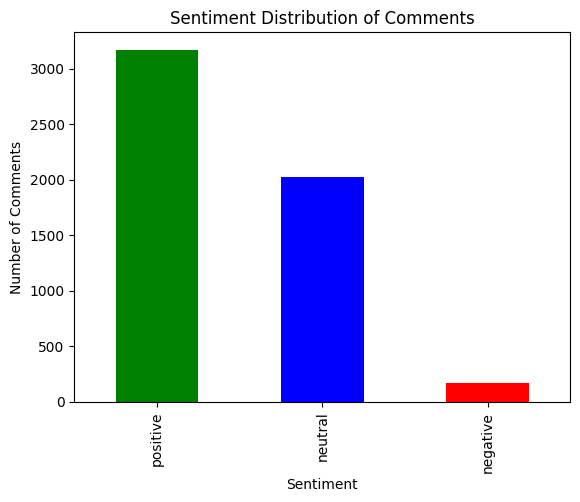

In [34]:
import matplotlib.pyplot as plt

# Count the number of comments for each sentiment label
sentiment_counts = comments_df['sentiment'].value_counts()
sentiment_counts.plot(kind='bar', color=['green', 'blue', 'red'])
plt.xlabel('Sentiment')
plt.ylabel('Number of Comments')
plt.title('Sentiment Distribution of Comments')
plt.show()


In [35]:
comments_df.head()

,post_id,commentUser,timestamp,comments,clean_comments,tokens,polarity,sentiment,tfidf_keywords,preferences,emoji_present
0,1,wilsonjunior5055,2023-06-05 12:27:24+00:00,"I have a proposal for u, send me a DM please!",i have a proposal for u send me a dm please,"[proposal, u, send, dm, please]",0.00,neutral,"[please, amazing, beautiful, clapping_hands, de]",[],[]
1,1,mariavmh,2023-06-04 16:46:40+00:00,Woaaaah,woaaaah,[woaaaah],0.00,neutral,"[amazing, beautiful, clapping_hands, de, fire]",[],[]
2,1,mariavmh,2023-06-04 16:46:34+00:00,:smiling_face_with_heart-eyes::smiling_face_wi...,smiling_face_with_hearteyessmiling_face_with_h...,[smiling_face_with_hearteyessmiling_face_with_...,0.96,positive,"[amazing, beautiful, clapping_hands, de, fire]",[],[]
3,1,stylemesoftly_,2023-06-04 15:44:54+00:00,:red_heart:️:red_heart:️:red_heart:️,red_heartred_heartred_heart,[red_heartred_heartred_heart],0.24,positive,"[red_heartred_heartred_heart, amazing, beautif...",[],[]
4,1,jillviv,2023-06-04 15:06:03+00:00,:smiling_face_with_heart-eyes::smiling_face_wi...,smiling_face_with_hearteyessmiling_face_with_h...,[smiling_face_with_hearteyessmiling_face_with_...,0.70,positive,[smiling_face_with_hearteyessmiling_face_with_...,[],[]


In [36]:
processed_comments_df = comments_df.drop(columns=['comments','preferences','emoji_present'])
processed_comments_df.head()

,post_id,commentUser,timestamp,clean_comments,tokens,polarity,sentiment,tfidf_keywords
0,1,wilsonjunior5055,2023-06-05 12:27:24+00:00,i have a proposal for u send me a dm please,"[proposal, u, send, dm, please]",0.00,neutral,"[please, amazing, beautiful, clapping_hands, de]"
1,1,mariavmh,2023-06-04 16:46:40+00:00,woaaaah,[woaaaah],0.00,neutral,"[amazing, beautiful, clapping_hands, de, fire]"
2,1,mariavmh,2023-06-04 16:46:34+00:00,smiling_face_with_hearteyessmiling_face_with_h...,[smiling_face_with_hearteyessmiling_face_with_...,0.96,positive,"[amazing, beautiful, clapping_hands, de, fire]"
3,1,stylemesoftly_,2023-06-04 15:44:54+00:00,red_heartred_heartred_heart,[red_heartred_heartred_heart],0.24,positive,"[red_heartred_heartred_heart, amazing, beautif..."
4,1,jillviv,2023-06-04 15:06:03+00:00,smiling_face_with_hearteyessmiling_face_with_h...,[smiling_face_with_hearteyessmiling_face_with_...,0.70,positive,[smiling_face_with_hearteyessmiling_face_with_...


In [37]:
comments_df.to_csv('new_comments.csv', index=False)

In [38]:
processed_comments_df = processed_comments_df.groupby("post_id").agg({
    "polarity": "mean",  # Tính trung bình cảm xúc,
    "tfidf_keywords": lambda x: ' '.join(x.dropna().astype(str))  # Nối các từ khóa lại thành 1 chuỗi

}).reset_index()

In [39]:
processed_posts_df.rename(columns={"keywords_tfidf": "keywords_tfidf_posts"}, inplace=True)

processed_posts_df.head()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24984\3104218378.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  processed_posts_df.rename(columns={"keywords_tfidf": "keywords_tfidf_posts"}, inplace=True)


,post_id,postUser,timestamp,clean_caption,combined_tokens,likesCount,commentsCount,keywords_tfidf_posts,keywords_freq,keywords_weighted
0,1,maryleest,2023-06-02 16:34:43+00:00,cannes 2023 with kilianparis 🤍 kiliancannes we...,"[cannes, 2023, kilianparis, kiliancannes, wear...",32070,142,"[cannes, wearing, dress, white, 2023]","[cannes, 2023, kilianparis, kiliancannes, wear...","[kiliancannes, kilianparis, cannes, kilian, we..."
1,2,tinaabeysekara,2023-01-01 07:49:16+00:00,as the clock struck midnight to ring in 2022 i...,"[clock, struck, midnight, ring, 2022, cried, w...",6565,86,"[year, 2022, ever, medium, face]","[year, 2022, ever, thank, 2023]","[2022, 2023, clock, struck, midnight]"
2,3,maryleest,2023-05-29 18:57:51+00:00,the famous stairs 🤎 photo gustave_durin dress ...,"[famous, stairs, photo, gustave_durin, dress, ...",28936,123,"[gustave_durin, yessayan, brown, famous, marma...","[famous, stairs, photo, gustave_durin, dress]","[dress, jewelry, balmainhaircouture, famous, s..."
3,4,stephaniebroek,2023-03-07 19:30:42+00:00,i visualized this moment so many times before ...,"[visualized, moment, many, times, first, chane...",4764,215,"[editor, flower, moment, chanel, show]","[editor, moment, show, chanel, flower]","[show, chanelofficial, chanel, chanelfallwinte..."
4,5,maryleest,2023-05-23 21:11:12+00:00,got to witness such historical moment in cinem...,"[got, witness, historical, moment, cinema, kil...",13379,123,"[cannes, cinema, historical, witness, killers]","[cannes, got, witness, historical, moment]","[cannes, cannesfilmfestival, festival, got, wi..."


In [40]:
#Rename columns "tfidf_keywords"
processed_comments_df.rename(columns={"tfidf_keywords": "keywords_tfidf_comments"}, inplace=True)
processed_comments_df.head()

,post_id,polarity,keywords_tfidf_comments
0,1,0.403500,"['please', 'amazing', 'beautiful', 'clapping_h..."
1,2,0.316667,"['amazing', 'beautiful', 'clapping_hands', 'de..."
2,3,0.400000,"['fire', 'love', 'look', 'firefirefire', 'amaz..."
3,4,0.168889,"['amazing', 'beautiful', 'clapping_hands', 'de..."
4,5,0.401000,"['amazing', 'beautiful', 'clapping_hands', 'de..."


In [41]:
df = pd.merge(processed_posts_df, processed_comments_df, on='post_id', how='left')
df.head()


,post_id,postUser,timestamp,clean_caption,combined_tokens,likesCount,commentsCount,keywords_tfidf_posts,keywords_freq,keywords_weighted,polarity,keywords_tfidf_comments
0,1,maryleest,2023-06-02 16:34:43+00:00,cannes 2023 with kilianparis 🤍 kiliancannes we...,"[cannes, 2023, kilianparis, kiliancannes, wear...",32070,142,"[cannes, wearing, dress, white, 2023]","[cannes, 2023, kilianparis, kiliancannes, wear...","[kiliancannes, kilianparis, cannes, kilian, we...",0.403500,"['please', 'amazing', 'beautiful', 'clapping_h..."
1,2,tinaabeysekara,2023-01-01 07:49:16+00:00,as the clock struck midnight to ring in 2022 i...,"[clock, struck, midnight, ring, 2022, cried, w...",6565,86,"[year, 2022, ever, medium, face]","[year, 2022, ever, thank, 2023]","[2022, 2023, clock, struck, midnight]",0.316667,"['amazing', 'beautiful', 'clapping_hands', 'de..."
2,3,maryleest,2023-05-29 18:57:51+00:00,the famous stairs 🤎 photo gustave_durin dress ...,"[famous, stairs, photo, gustave_durin, dress, ...",28936,123,"[gustave_durin, yessayan, brown, famous, marma...","[famous, stairs, photo, gustave_durin, dress]","[dress, jewelry, balmainhaircouture, famous, s...",0.400000,"['fire', 'love', 'look', 'firefirefire', 'amaz..."
3,4,stephaniebroek,2023-03-07 19:30:42+00:00,i visualized this moment so many times before ...,"[visualized, moment, many, times, first, chane...",4764,215,"[editor, flower, moment, chanel, show]","[editor, moment, show, chanel, flower]","[show, chanelofficial, chanel, chanelfallwinte...",0.168889,"['amazing', 'beautiful', 'clapping_hands', 'de..."
4,5,maryleest,2023-05-23 21:11:12+00:00,got to witness such historical moment in cinem...,"[got, witness, historical, moment, cinema, kil...",13379,123,"[cannes, cinema, historical, witness, killers]","[cannes, got, witness, historical, moment]","[cannes, cannesfilmfestival, festival, got, wi...",0.401000,"['amazing', 'beautiful', 'clapping_hands', 'de..."


In [42]:
final_df = df.copy()

final_df['keywords_posts'] = final_df.apply(lambda row: list(set(row['keywords_tfidf_posts'] + row['keywords_freq'] + row['keywords_weighted'])), axis=1)
final_df = final_df.drop(columns=['keywords_tfidf_posts', 'keywords_freq', 'keywords_weighted','clean_caption'])
# Rename columns "polarity" and "keywords_tfidf_comments"
final_df = final_df.rename(columns={"polarity": "score_segtiment", "keywords_tfidf_comments": "keywords_comments"})
final_df.head()

,post_id,postUser,timestamp,combined_tokens,likesCount,commentsCount,score_segtiment,keywords_comments,keywords_posts
0,1,maryleest,2023-06-02 16:34:43+00:00,"[cannes, 2023, kilianparis, kiliancannes, wear...",32070,142,0.403500,"['please', 'amazing', 'beautiful', 'clapping_h...","[white, kiliancannes, dress, kilian, 2023, wea..."
1,2,tinaabeysekara,2023-01-01 07:49:16+00:00,"[clock, struck, midnight, ring, 2022, cried, w...",6565,86,0.316667,"['amazing', 'beautiful', 'clapping_hands', 'de...","[ever, medium, 2022, thank, year, clock, midni..."
2,3,maryleest,2023-05-29 18:57:51+00:00,"[famous, stairs, photo, gustave_durin, dress, ...",28936,123,0.400000,"['fire', 'love', 'look', 'firefirefire', 'amaz...","[famous, brown, jewelry, yessayan, marmarhalim..."
3,4,stephaniebroek,2023-03-07 19:30:42+00:00,"[visualized, moment, many, times, first, chane...",4764,215,0.168889,"['amazing', 'beautiful', 'clapping_hands', 'de...","[moment, chanelofficial, fashion, flower, show..."
4,5,maryleest,2023-05-23 21:11:12+00:00,"[got, witness, historical, moment, cinema, kil...",13379,123,0.401000,"['amazing', 'beautiful', 'clapping_hands', 'de...","[witness, moment, cannesfilmfestival, got, his..."


In [43]:
final_df.to_csv('final_df.csv', index=False)

In [44]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 827 entries, 0 to 826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   post_id            827 non-null    int64              
 1   postUser           827 non-null    object             
 2   timestamp          827 non-null    datetime64[ns, UTC]
 3   combined_tokens    827 non-null    object             
 4   likesCount         827 non-null    int64              
 5   commentsCount      827 non-null    int64              
 6   score_segtiment    755 non-null    float64            
 7   keywords_comments  756 non-null    object             
 8   keywords_posts     827 non-null    object             
dtypes: datetime64[ns, UTC](1), float64(1), int64(3), object(4)
memory usage: 58.3+ KB
